In [2]:
# ==========================
# Cell 1：查看数据基本信息
# ==========================

import pandas as pd

# 修改成你的文件路径
file_path = "训练集_20180101-0124_拖轮AIS.csv"

df = pd.read_csv(file_path)

# 查看前5行
print("===== 前5行数据 =====")
print(df.head())

print("\n===== 数据维度 =====")
print(df.shape)

print("\n===== 每列数据类型 =====")
print(df.dtypes)

print("\n===== DataFrame信息 =====")
print(df.info())

print("\n===== 缺失值统计 =====")
print(df.isnull().sum())

print("\n===== 每列唯一值数量 =====")
print(df.nunique())
# ==========================
# Cell 2：查看每列示例值及Python类型
# ==========================

for col in df.columns:
    print("=" * 60)
    print(f"列名：{col}")
    print(f"Pandas类型：{df[col].dtype}")
    print(f"Python类型：{type(df[col].iloc[0])}")
    print("前5个值：")
    print(df[col].head().tolist())

===== 前5行数据 =====
   mmsi           x          y         cog  true_heading  sog         rot  \
0  1119  117.789772  38.975652  295.200012          21.0  0.0    0.000000   
1  3019  117.790202  38.968270  317.000000         209.0  2.1  720.003235   
2  1119  117.777335  38.999128  154.100006         155.0  6.9    0.000000   
3  3080  117.774093  39.006663  172.600006         260.0  0.0    0.000000   
4  1051  117.789400  38.975533  230.100006         179.0  0.0    0.000000   

                  time source_dataset ship_type  
0  2018-01-01 02:41:47  china_coastal       Tug  
1  2018-01-01 03:41:29  china_coastal       Tug  
2  2018-01-01 07:51:33  china_coastal       Tug  
3  2018-01-01 07:57:01  china_coastal       Tug  
4  2018-01-01 08:15:31  china_coastal       Tug  

===== 数据维度 =====
(2039846, 10)

===== 每列数据类型 =====
mmsi                int64
x                 float64
y                 float64
cog               float64
true_heading      float64
sog               float64
rot        

   mmsi           x          y         cog  true_heading  sog         rot  \
0  1119  117.789772  38.975652  295.200012          21.0  0.0    0.000000   
1  3019  117.790202  38.968270  317.000000         209.0  2.1  720.003235   
2  1119  117.777335  38.999128  154.100006         155.0  6.9    0.000000   
3  3080  117.774093  39.006663  172.600006         260.0  0.0    0.000000   
4  1051  117.789400  38.975533  230.100006         179.0  0.0    0.000000   

                 time source_dataset ship_type        date  day  hour  minute  \
0 2018-01-01 02:41:47  china_coastal       Tug  2018-01-01    1     2      41   
1 2018-01-01 03:41:29  china_coastal       Tug  2018-01-01    1     3      41   
2 2018-01-01 07:51:33  china_coastal       Tug  2018-01-01    1     7      51   
3 2018-01-01 07:57:01  china_coastal       Tug  2018-01-01    1     7      57   
4 2018-01-01 08:15:31  china_coastal       Tug  2018-01-01    1     8      15   

   weekday weekday_name         time_window  
0   

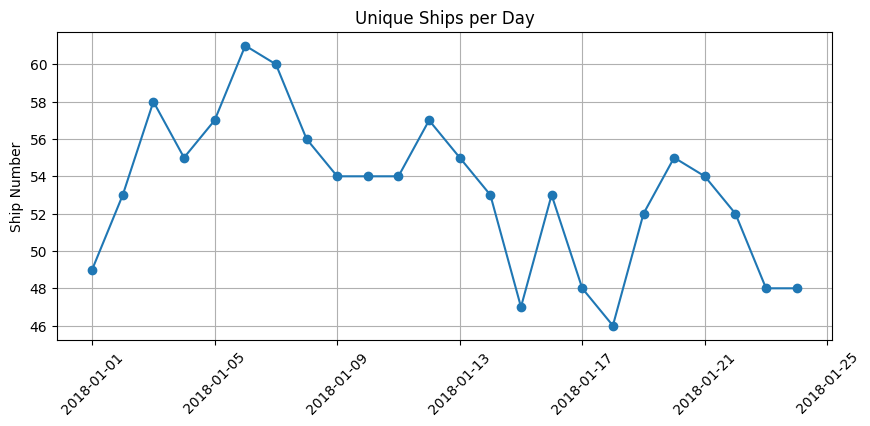

In [3]:
# ============================================
# Cell 1 数据预处理
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 显示所有列
pd.set_option("display.max_columns", None)

# 读取数据
df = pd.read_csv("训练集_20180101-0124_拖轮AIS.csv")

# 时间转换
df["time"] = pd.to_datetime(df["time"])

# 衍生时间字段
df["date"] = df["time"].dt.date                  # 日期
df["day"] = df["time"].dt.day                    # 一个月中的第几天
df["hour"] = df["time"].dt.hour                  # 小时
df["minute"] = df["time"].dt.minute              # 分钟
df["weekday"] = df["time"].dt.dayofweek          # 星期（0=周一）
df["weekday_name"] = df["time"].dt.day_name()    # Monday...

# 比赛按1小时统计
df["time_window"] = df["time"].dt.floor("h")

print(df.head())

print("\n数据规模：", df.shape)

print("\n时间范围：")
print(df["time"].min())
print(df["time"].max())
# ============================================
# Cell 3 每天船舶数量
# ============================================
daily_ship = (
    df.groupby("date")["mmsi"]
      .nunique()
      .reset_index(name="ship_num")
)

print(daily_ship)

plt.figure(figsize=(10,4))
plt.plot(daily_ship["date"], daily_ship["ship_num"], marker="o")
plt.xticks(rotation=45)
plt.grid(True)
plt.title("Unique Ships per Day")
plt.ylabel("Ship Number")
plt.show()

          date  record_num
0   2018-01-01      113491
1   2018-01-02      149794
2   2018-01-03      141403
3   2018-01-04      104676
4   2018-01-05      130152
5   2018-01-06      134287
6   2018-01-07      101437
7   2018-01-08      140953
8   2018-01-09       81419
9   2018-01-10       69851
10  2018-01-11       89923
11  2018-01-12       40369
12  2018-01-13       10621
13  2018-01-14        6849
14  2018-01-15        6632
15  2018-01-16        9971
16  2018-01-17        7786
17  2018-01-18       10271
18  2018-01-19       81147
19  2018-01-20      129476
20  2018-01-21      139585
21  2018-01-22      136958
22  2018-01-23       96934
23  2018-01-24      105861


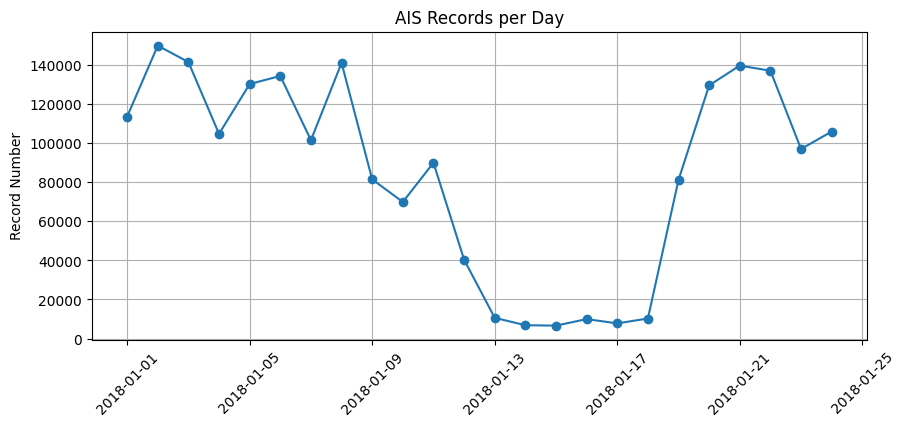

In [4]:
# ============================================
# Cell 4 每天AIS记录数量
# ============================================

daily_record = (
    df.groupby("date")
      .size()
      .reset_index(name="record_num")
)

print(daily_record)

plt.figure(figsize=(10,4))
plt.plot(daily_record["date"], daily_record["record_num"], marker="o")
plt.xticks(rotation=45)
plt.grid(True)
plt.title("AIS Records per Day")
plt.ylabel("Record Number")
plt.show()

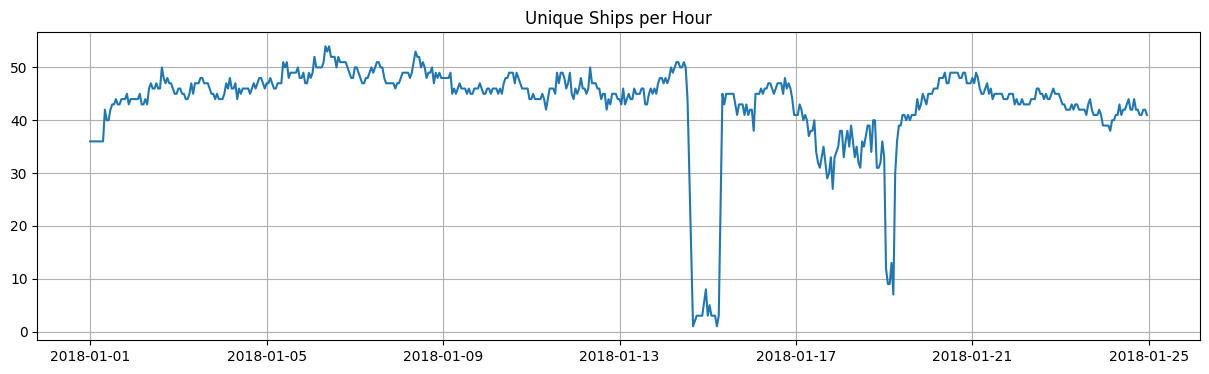

In [5]:
# ============================================
# Cell 5 每小时船舶数量
# ============================================

hour_ship = (
    df.groupby("time_window")["mmsi"]
      .nunique()
      .reset_index(name="ship_num")
)

plt.figure(figsize=(15,4))
plt.plot(hour_ship["time_window"], hour_ship["ship_num"])
plt.grid(True)
plt.title("Unique Ships per Hour")
plt.show()

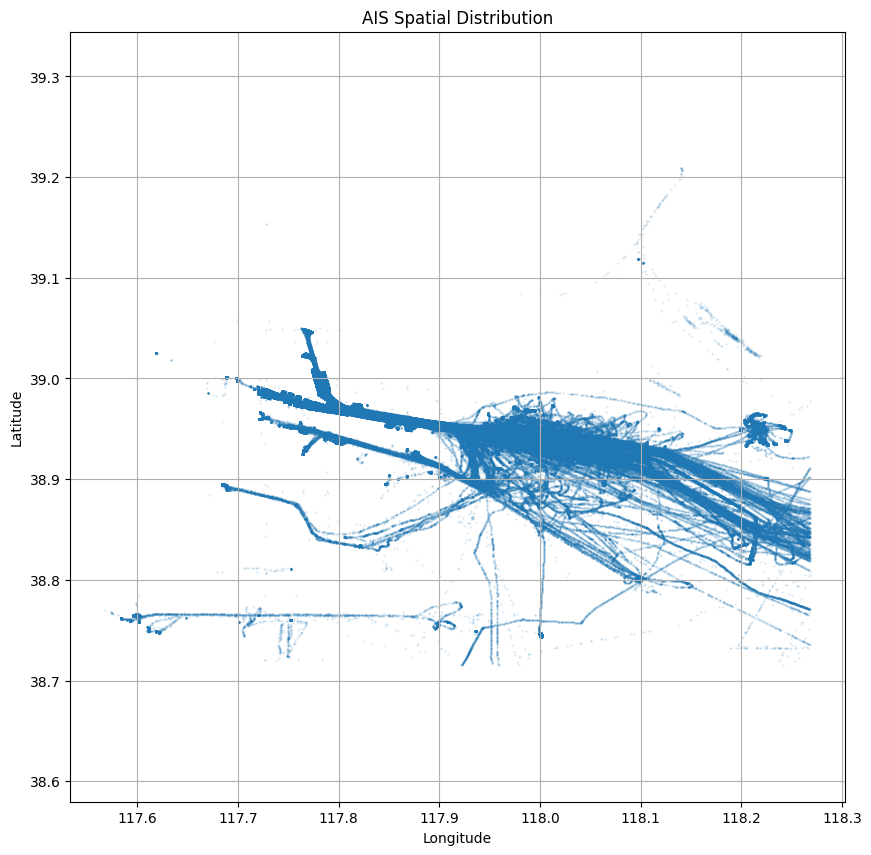

In [6]:
# ============================================
# 所有AIS点空间分布
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.scatter(
    df["x"],
    df["y"],
    s=0.2,          # 点尽量小
    alpha=0.2
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("AIS Spatial Distribution")

plt.axis("equal")
plt.grid(True)

plt.show()

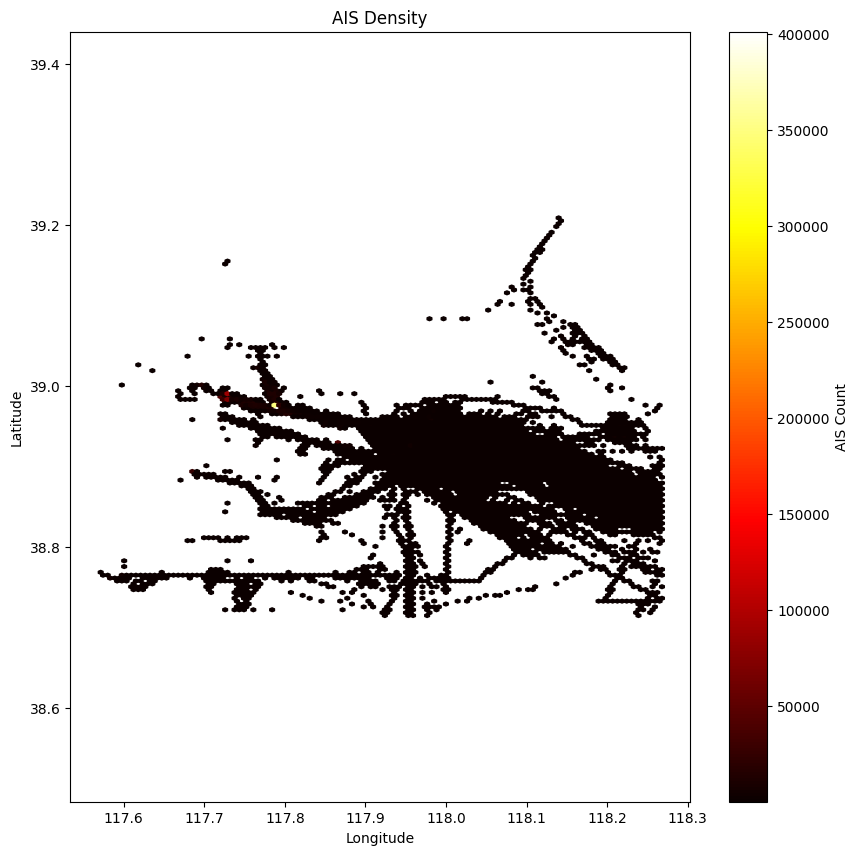

In [8]:
# ============================================
# 二维密度图
# ============================================

plt.figure(figsize=(10,10))

plt.hexbin(
    df["x"],
    df["y"],
    gridsize=120,
    cmap="hot",
    mincnt=1
)

plt.colorbar(label="AIS Count")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("AIS Density")

plt.axis("equal")

plt.show()

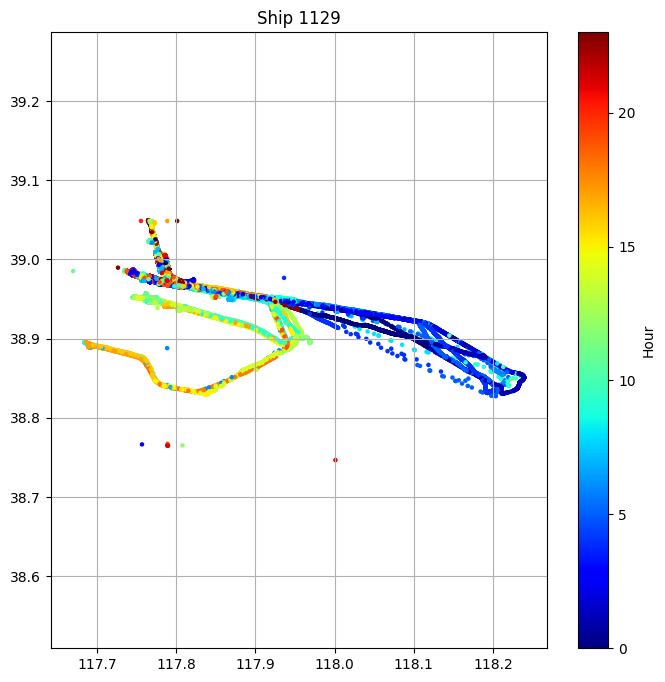

In [11]:
ship_id = df["mmsi"].unique()[4]

ship = df[df["mmsi"] == ship_id].copy()

plt.figure(figsize=(8,8))

plt.scatter(
    ship["x"],
    ship["y"],
    c=ship["time"].dt.hour,
    cmap="jet",
    s=5
)

plt.colorbar(label="Hour")

plt.axis("equal")
plt.grid(True)

plt.title(f"Ship {ship_id}")
plt.show()

count    2.039846e+06
mean     5.608215e+00
std      8.332982e+00
min      1.440855e-03
25%      5.823213e-01
50%      2.213732e+00
75%      6.040568e+00
max      4.896194e+01
Name: distance_km, dtype: float64
mmsi
3077    133961
1129    133475
1119    132440
1087    131822
3080    130014
Name: count, dtype: int64
选择船: 3077


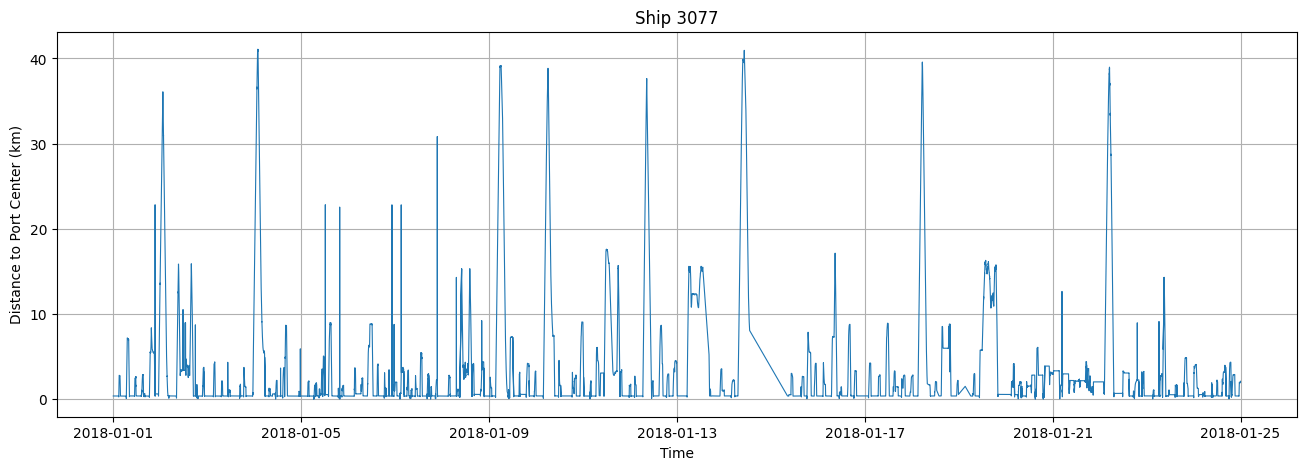

In [12]:
# ============================================
# Cell 计算距离港口中心
# ============================================

import numpy as np

CENTER_LON = 117.79
CENTER_LAT = 38.97

R = 6371.0  # 地球半径(km)

lon1 = np.radians(df["x"])
lat1 = np.radians(df["y"])

lon2 = np.radians(CENTER_LON)
lat2 = np.radians(CENTER_LAT)

dlon = lon1 - lon2
dlat = lat1 - lat2

a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = R * c

print(df["distance_km"].describe())
# ============================================
# 找记录最多的船
# ============================================

ship_count = df["mmsi"].value_counts()

print(ship_count.head())

ship_id = ship_count.index[0]

print("选择船:", ship_id)
# ============================================
# 时间-空间图
# ============================================

import matplotlib.pyplot as plt

ship = df[df["mmsi"] ==1129].sort_values("time")

plt.figure(figsize=(16,5))

plt.plot(
    ship["time"],
    ship["distance_km"],
    lw=0.8
)

plt.xlabel("Time")
plt.ylabel("Distance to Port Center (km)")
plt.title(f"Ship {ship_id}")

plt.grid(True)

plt.show()

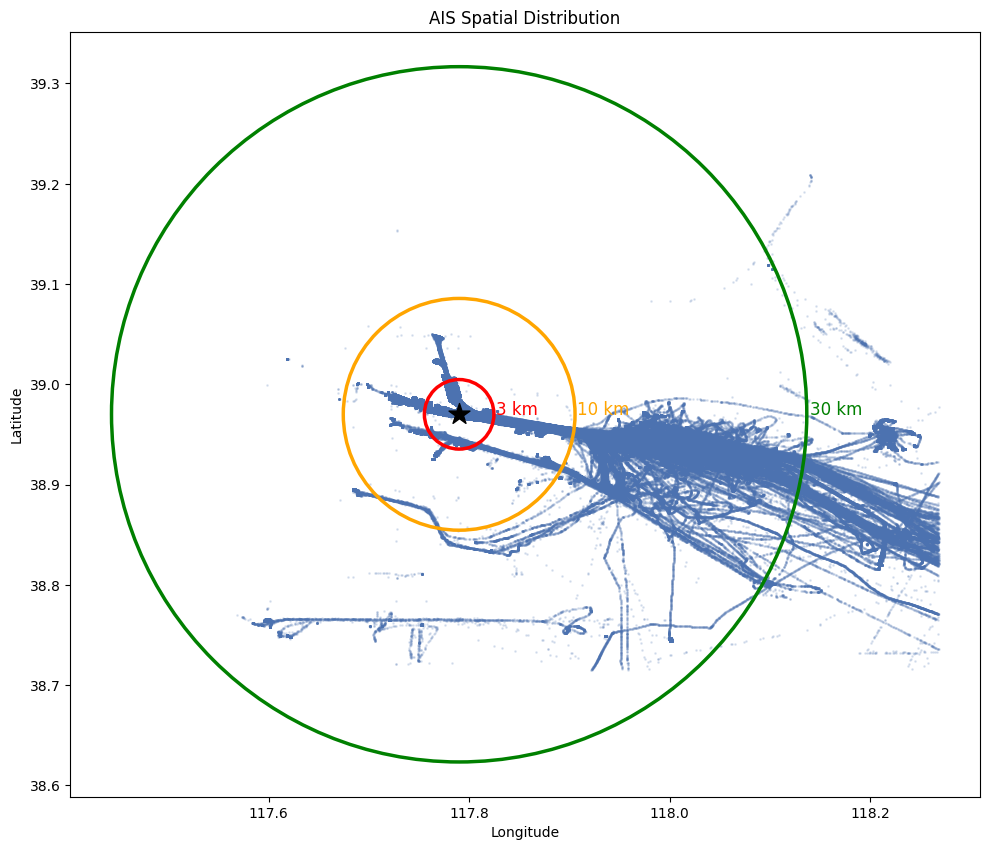

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ==========================
# 随机抽样（避免240万点）
# ==========================
sample = df.sample(
    n=len(df),
    random_state=42
)

CENTER_LON = 117.79
CENTER_LAT = 38.97

# 经纬度换算
km_per_deg_lon = 111.32 * np.cos(np.radians(CENTER_LAT))

r3 = 3 / km_per_deg_lon
r10 = 10 / km_per_deg_lon
r30 = 30 / km_per_deg_lon

fig, ax = plt.subplots(figsize=(10,10))

# 所有点
ax.scatter(
    sample["x"],
    sample["y"],
    s=1,
    alpha=0.15,
    color="#4C72B0"
)

# 三个圈
for r, c in zip(
    [r3, r10, r30],
    ["red","orange","green"]
):
    ax.add_patch(
        Circle(
            (CENTER_LON, CENTER_LAT),
            r,
            fill=False,
            lw=2.5,
            color=c
        )
    )

# 中心点
ax.scatter(
    CENTER_LON,
    CENTER_LAT,
    marker="*",
    s=250,
    c="black",
    label="Port Center"
)

# 加文字
ax.text(
    CENTER_LON + r3*1.05,
    CENTER_LAT,
    "3 km",
    color="red",
    fontsize=12
)

ax.text(
    CENTER_LON + r10*1.02,
    CENTER_LAT,
    "10 km",
    color="orange",
    fontsize=12
)

ax.text(
    CENTER_LON + r30*1.01,
    CENTER_LAT,
    "30 km",
    color="green",
    fontsize=12
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("AIS Spatial Distribution")

ax.set_aspect("equal")

plt.tight_layout()

plt.show()

In [19]:
import pandas as pd
import folium

# =====================================================
# 参数设置
# =====================================================

# 时间范围（建议先看3天）
START_DATE = "2018-01-01"
END_DATE = "2018-01-04"      # 注意这里是开区间，所以看到的是1、2、3号

# 如果知道船号，就填，例如1119；否则设为None自动选择记录最多的船
SHIP_ID = None

# 每隔多少分钟保留一个AIS点（防止太密）
RESAMPLE_MIN = "10min"

# 港口中心
CENTER = [38.97, 117.79]

# =====================================================
# 数据筛选
# =====================================================

df_show = df[
    (df["time"] >= START_DATE) &
    (df["time"] < END_DATE)
].copy()

# 自动选择记录最多的船
if SHIP_ID is None:
    SHIP_ID = df_show["mmsi"].value_counts().idxmax()

print(f"当前船舶：{SHIP_ID}")

ship_df = (
    df_show[df_show["mmsi"] == SHIP_ID]
    .sort_values("time")
    .set_index("time")
    .resample(RESAMPLE_MIN)
    .first()
    .dropna()
    .reset_index()
)

print(ship_df.head())

# =====================================================
# 建立地图
# =====================================================

m = folium.Map(
    location=CENTER,
    zoom_start=12,
    tiles="OpenStreetMap"
)

# =====================================================
# 比赛三个圈层
# =====================================================

folium.Circle(
    CENTER,
    radius=3000,
    color="red",
    weight=2,
    fill=False,
    tooltip="Core (0-3 km)"
).add_to(m)

folium.Circle(
    CENTER,
    radius=10000,
    color="orange",
    weight=2,
    fill=False,
    tooltip="Near Port (3-10 km)"
).add_to(m)

folium.Circle(
    CENTER,
    radius=30000,
    color="green",
    weight=2,
    fill=False,
    tooltip="Outer (10-30 km)"
).add_to(m)

# 港口中心
folium.Marker(
    CENTER,
    popup="Port Center",
    icon=folium.Icon(color="black", icon="info-sign")
).add_to(m)

# =====================================================
# 每天一种颜色
# =====================================================

colors = [
    "red",
    "blue",
    "green",
    "purple",
    "orange",
    "black",
    "pink",
    "cadetblue",
    "darkred",
    "darkgreen",
]

dates = sorted(ship_df["time"].dt.date.unique())

for i, d in enumerate(dates):

    color = colors[i % len(colors)]

    day_df = ship_df[
        ship_df["time"].dt.date == d
    ]

    for _, row in day_df.iterrows():

        folium.CircleMarker(
            location=[row["y"], row["x"]],
            radius=3,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=f"{row['time']}"
        ).add_to(m)

# =====================================================
# 保存
# =====================================================

m.save(f"ship_{SHIP_ID}.html")

print(f"已保存：ship_{SHIP_ID}.html")


当前船舶：1129
                 time  mmsi           x          y         cog  true_heading  \
0 2018-01-01 00:00:00  1129  117.788583  38.973250  350.700012         219.0   
1 2018-01-01 00:10:00  1129  117.788600  38.973250  350.700012         220.0   
2 2018-01-01 00:20:00  1129  117.788600  38.973267  350.700012         219.0   
3 2018-01-01 00:30:00  1129  117.788600  38.973283  350.700012         219.0   
4 2018-01-01 00:40:00  1129  117.788600  38.973283  350.700012         219.0   

   sog  rot source_dataset ship_type        date  day  hour  minute  weekday  \
0  0.0  0.0  china_coastal       Tug  2018-01-01    1     0       0        0   
1  0.0  0.0  china_coastal       Tug  2018-01-01    1     0      10        0   
2  0.0  0.0  china_coastal       Tug  2018-01-01    1     0      20        0   
3  0.0  0.0  china_coastal       Tug  2018-01-01    1     0      30        0   
4  0.0  0.0  china_coastal       Tug  2018-01-01    1     0      40        0   

  weekday_name time_window  